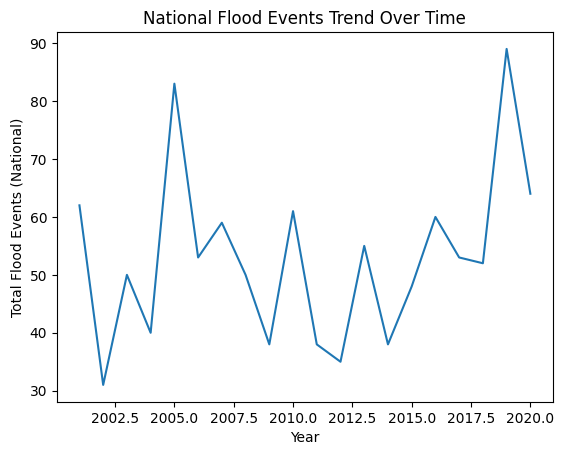

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Final_Cleaned_Panel_Dataset.csv")

national_trend = df.groupby("Year")["Total_Flood_Events"].sum()

plt.figure()
plt.plot(national_trend.index, national_trend.values)
plt.title("National Flood Events Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Flood Events (National)")
plt.show()

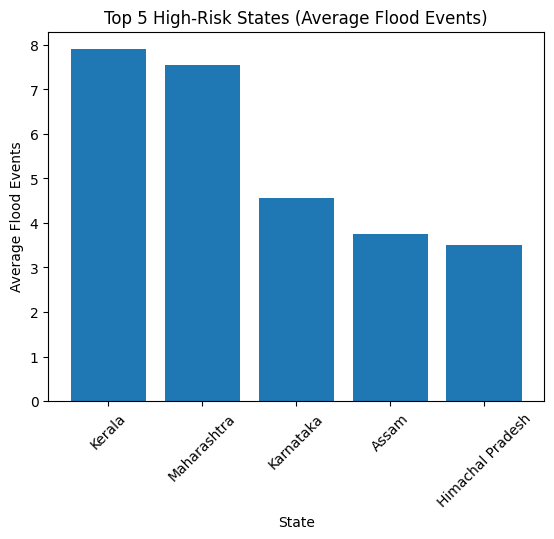

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Final_Cleaned_Panel_Dataset.csv")

state_risk = (
    df.groupby("State")["Total_Flood_Events"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure()
plt.bar(state_risk.index, state_risk.values)
plt.title("Top 5 High-Risk States (Average Flood Events)")
plt.xlabel("State")
plt.ylabel("Average Flood Events")
plt.xticks(rotation=45)
plt.show()

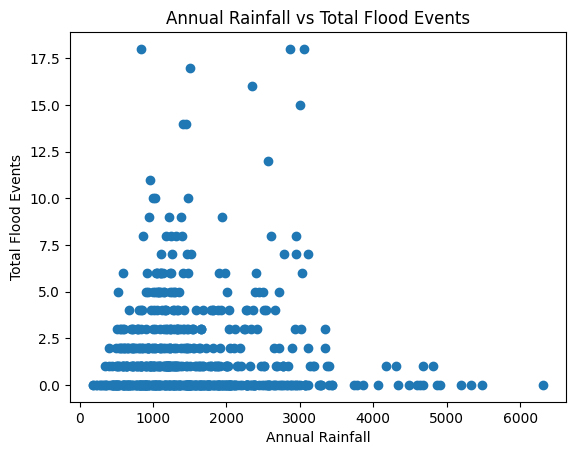

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Final_Cleaned_Panel_Dataset.csv")

plt.figure()
plt.scatter(df["Annual_Rainfall"], df["Total_Flood_Events"])
plt.title("Annual Rainfall vs Total Flood Events")
plt.xlabel("Annual Rainfall")
plt.ylabel("Total Flood Events")
plt.show()

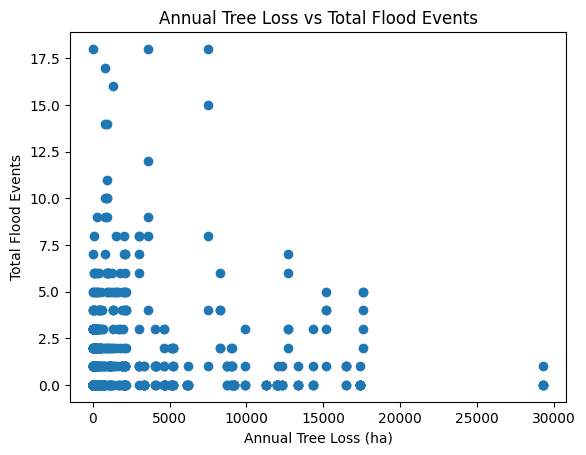

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Final_Cleaned_Panel_Dataset.csv")

plt.figure()
plt.scatter(df["Annual_Tree_Loss_ha"], df["Total_Flood_Events"])
plt.title("Annual Tree Loss vs Total Flood Events")
plt.xlabel("Annual Tree Loss (ha)")
plt.ylabel("Total Flood Events")
plt.show()

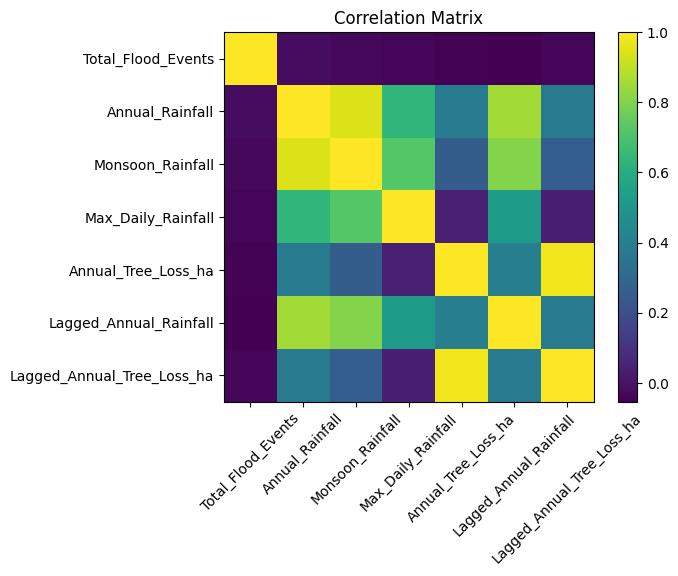

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Final_Cleaned_Panel_Dataset.csv")

features = [
    "Total_Flood_Events",
    "Annual_Rainfall",
    "Monsoon_Rainfall",
    "Max_Daily_Rainfall",
    "Annual_Tree_Loss_ha",
    "Lagged_Annual_Rainfall",
    "Lagged_Annual_Tree_Loss_ha"
]

corr_matrix = df[features].corr()

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(features)), features)
plt.title("Correlation Matrix")
plt.show()

<Figure size 640x480 with 0 Axes>

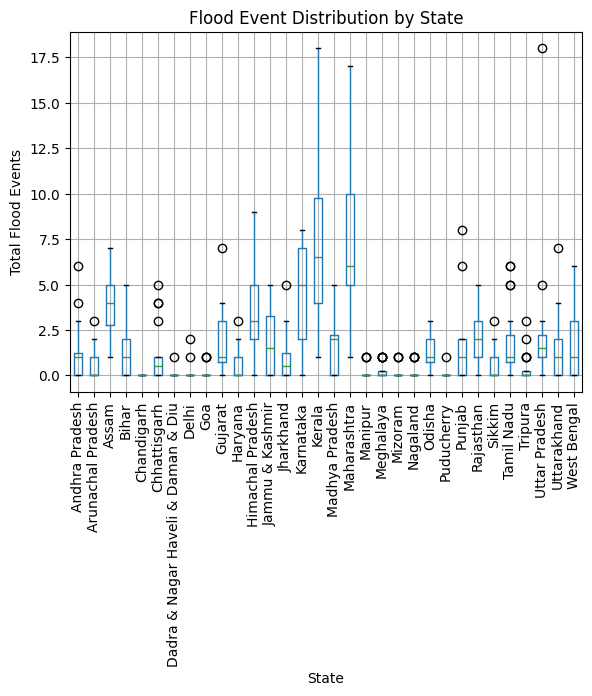

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Final_Cleaned_Panel_Dataset.csv")

plt.figure()
df.boxplot(column="Total_Flood_Events", by="State", rot=90)
plt.title("Flood Event Distribution by State")
plt.suptitle("")
plt.xlabel("State")
plt.ylabel("Total Flood Events")
plt.show()

In [1]:
import pandas as pd
import pymannkendall as mk

# Load dataset
df = pd.read_csv("Final_Cleaned_Panel_Dataset.csv")

# Aggregate national flood events per year
national_flood = df.groupby("Year")["Total_Flood_Events"].sum()

# Run Mann-Kendall Test
result = mk.original_test(national_flood)

print("Mann-Kendall Test for National Flood Events")
print("Trend:", result.trend)
print("p-value:", result.p)
print("Tau:", result.Tau)
print("Slope:", result.slope)

Mann-Kendall Test for National Flood Events
Trend: no trend
p-value: 0.3975089224120554
Tau: 0.14210526315789473
Slope: 0.4642857142857143


In [2]:
# Aggregate national rainfall per year (mean)
national_rainfall = df.groupby("Year")["Annual_Rainfall"].mean()

result_rain = mk.original_test(national_rainfall)

print("Mann-Kendall Test for National Rainfall")
print("Trend:", result_rain.trend)
print("p-value:", result_rain.p)
print("Tau:", result_rain.Tau)
print("Slope:", result_rain.slope)

Mann-Kendall Test for National Rainfall
Trend: no trend
p-value: 0.2843217140080183
Tau: 0.17894736842105263
Slope: 5.7306021390321025


In [3]:
# Aggregate national tree loss per year (sum)
national_tree_loss = df.groupby("Year")["Annual_Tree_Loss_ha"].sum()

result_tree = mk.original_test(national_tree_loss)

print("Mann-Kendall Test for National Tree Loss")
print("Trend:", result_tree.trend)
print("p-value:", result_tree.p)
print("Tau:", result_tree.Tau)
print("Slope:", result_tree.slope)

Mann-Kendall Test for National Tree Loss
Trend: increasing
p-value: 5.350352678679116e-07
Tau: 0.7894736842105263
Slope: 5393.2125000000015
